In [7]:
import numpy as np
from scipy.signal import resample_poly, spectrogram
import matplotlib.pyplot as plt
import sys
import os
import torch
# add parent folder (production) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAMv4

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


In [8]:
sf = 7
bw = 125000
fs = 1000000
lora_init = LoRa(sf, bw)
input_row = 128
input_col = 33
## HOW TO LOAD WEIGHT
layers = [input_col * input_row, 1024, 256] # <-- must match training

multi_bam = MultiBAMv4(layers_dims=layers, eta=1e-5)
# for i, bam in enumerate(multi_bam.bams):
#     bam.W = np.load(f"weight_3840_1024_256_model2/weights_layer_{i}.npy")

for i, bam in enumerate(multi_bam.bams):
    w_np = np.load(f"weight_{input_row*input_col}_1024_256/weights_layer_{i}.npy")
    bam.W = torch.tensor(w_np, dtype=torch.float32, device=bam.device)
    print(f"Loaded layer {i}: shape {bam.W.shape}")


Loaded layer 0: shape torch.Size([1024, 4224])
Loaded layer 1: shape torch.Size([256, 1024])


torch.Size([1, 2, 128, 33])
torch.Size([1, 2, 128, 33])
torch.Size([128, 33])
aaaaaaaaaaaaaaaaaa torch.Size([1, 4224])
(128, 33)


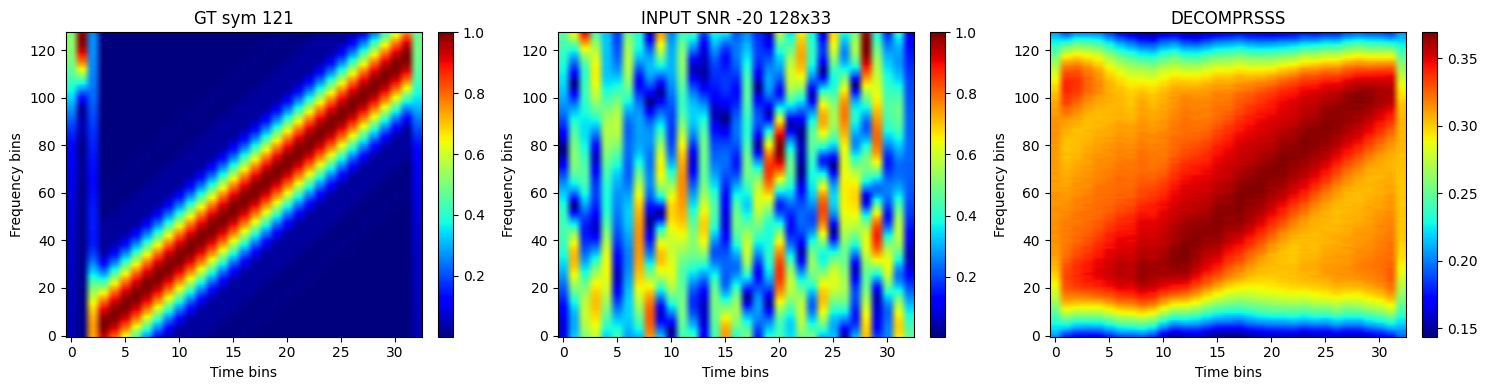

RMSE :  0.2143681649034802
RMPE :  0.04595371012408568
RMSE - to signal max ratio = 58.038 %
RMSE - to signal mean ratio = 70.040 %
Error Vector Magnitude = 0.499 => 49.867 %
RMSE :  0.3228190943230129
RMPE :  0.10421216765953031
RMSE - to signal max ratio = 87.400 %
RMSE - to signal mean ratio = 105.474 %
Error Vector Magnitude = 0.780 => 77.977 %


np.float64(0.3228190943230129)

In [ ]:
symbol1 = 128-7
symbol2 = 300
# EXAMPLE OF COMPRESS and DECOMPRESS
seed = None
x1 = lora_init.gen_symbol_fs(symbol1, sf=sf, bw=bw, Fs=1000000)  # you had Fs=int(bw*8)=1e6

original_pisan = create_spectrogram_from_torch(x1,sf,bw,1000000,input_row,input_col,0,0,1,None)

snr = -5
x = lora_init.awgn_iq_with_seed(x1,snr,seed)

aa = create_spectrogram_from_torch(x,sf,bw,1000000,input_row,input_col,0,0,1,None)
#### STEP 3 FLATTEN INPUT ########
print(aa.shape)
flat = aa.flatten().reshape(1, -1) # BEFORE COMPRESS MUST 
print("aaaaaaaaaaaaaaaaaa",flat.shape)
out1 = multi_bam.compress(flat)
out2 = multi_bam.decompress(out1)

#### STEP 4 AFTER DECOMPRESS RESHAPE to INITIAL SHAPE ########
reco_flat = out2.reshape(-1)  # AFTER DECOMPRESS MUST
reco_spec = reco_flat.reshape(input_row, input_col)
print(reco_spec.shape)

array_a = [original_pisan,aa,reco_spec]

show_multiple_spectrograms(array_a,[f'GT sym {symbol1}',f"INPUT SNR {snr} {input_row}x{input_col}","DECOMPRSSS"],3)
check_simmilarity(reco_spec,aa)
check_simmilarity(reco_spec,original_pisan)

